# 03 CNN+BiLSTM+Attention 情感模型训练

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/identifier


In [2]:
import sys
import time
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, random_split
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config
from utils.losses import FocalLoss
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation
from models.emotion_cnn_bilstm import EmotionRecognizer

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据

In [3]:
np.random.seed(cfg['training']['seed'])
torch.manual_seed(cfg['training']['seed'])

features_dir = cfg['paths']['features']
augmentation = AudioAugmentation()

datasets_train = []
datasets_plain = []
for subset in ('ravdess', 'casia'):
    d = os.path.join(features_dir, subset)
    if os.path.isdir(os.path.join(d, 'mel')):
        datasets_train.append(EmotionDataset(d, feature_type='mel', transform=augmentation))
        datasets_plain.append(EmotionDataset(d, feature_type='mel', transform=None))

full_train = ConcatDataset(datasets_train)
full_plain = ConcatDataset(datasets_plain)
total = len(full_plain)

train_n = int(total * cfg['training']['train_ratio'])
val_n = int(total * cfg['training']['val_ratio'])
test_n = total - train_n - val_n

gen = torch.Generator().manual_seed(cfg['training']['seed'])
train_idx, val_idx, test_idx = random_split(range(total), [train_n, val_n, test_n], generator=gen)

train_set = torch.utils.data.Subset(full_train, train_idx.indices)
val_set = torch.utils.data.Subset(full_plain, val_idx.indices)
test_set = torch.utils.data.Subset(full_plain, test_idx.indices)

bs = cfg['training']['batch_size']
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print(f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}')

EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
训练: 2112, 验证: 264, 测试: 264


## 2. 构建模型

In [4]:
model = EmotionRecognizer(
    num_classes=cfg['emotion']['num_classes'],
    n_mels=cfg['audio']['n_mels'],
    cnn_channels=tuple(cfg['model']['cnn_channels']),
    lstm_hidden=cfg['model']['lstm_hidden'],
    lstm_layers=cfg['model']['lstm_layers'],
    lstm_dropout=cfg['model']['dropout'],
    attn_dim=cfg['model']['attention_dim'],
    cls_hidden=cfg['model']['classifier_hidden'],
    cls_dropout=cfg['model']['classifier_dropout'],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型参数: {total_params:,} (可训练: {trainable_params:,})')
print(model)

模型参数: 1,371,518 (可训练: 1,371,518)
EmotionRecognizer(
  (cnn_blocks): ModuleList(
    (0): _ResidualCNNBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): _SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=8, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=8, out_features=32, bias=True)
          (3): Sigmoid()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (dropout): Dropout2d(p=0.1, inplace=False)
      (shortcut): Sequential(
        (0): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): _ResidualCNNBlock(
      (conv): Conv2d(32, 64, kernel_size

## 3. 训练

In [5]:
label_smoothing = cfg['training'].get('label_smoothing', 0.1)
use_focal = cfg['training'].get('focal_loss', False)
focal_gamma = cfg['training'].get('focal_gamma', 2.0)

if use_focal:
    criterion = FocalLoss(gamma=focal_gamma, label_smoothing=label_smoothing)
    print(f'损失函数: FocalLoss (gamma={focal_gamma}, label_smoothing={label_smoothing})')
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    print(f'损失函数: CrossEntropyLoss (label_smoothing={label_smoothing})')

base_lr = cfg['training']['learning_rate']
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=base_lr,
    weight_decay=cfg['training']['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5,
)
warmup_epochs = cfg['training'].get('warmup_epochs', 5)
print(f'优化器: AdamW (lr={base_lr}, warmup={warmup_epochs} epochs)')

epochs = cfg['training']['epochs']
patience = cfg['training']['patience']
best_val_loss = float('inf')
best_state = None
wait = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    
    if epoch <= warmup_epochs:
        lr = base_lr * (epoch / warmup_epochs)
        for g in optimizer.param_groups:
            g['lr'] = lr
    
    # 训练
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total += feats.size(0)
    
    # 验证
    model.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = model(feats)
            loss = criterion(logits, labels)
            vl_loss += loss.item() * feats.size(0)
            vl_correct += (logits.argmax(1) == labels).sum().item()
            vl_total += feats.size(0)
    
    tr_loss /= tr_total
    tr_acc = tr_correct / tr_total
    vl_loss /= vl_total
    vl_acc = vl_correct / vl_total
    
    if epoch > warmup_epochs:
        scheduler.step(vl_loss)
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    
    cur_lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'LR: {cur_lr:.6f} | {elapsed:.1f}s')
    
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        print(f'  -> 最佳模型已保存 (val_loss={vl_loss:.4f})')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 验证损失连续 {patience} 轮未改善')
            break

# 保存模型
os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save(best_state, cfg['paths']['best_emotion_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz'), **history)
print(f'\n模型已保存至: {cfg["paths"]["best_emotion_model"]}')

损失函数: CrossEntropyLoss (label_smoothing=0.1)
优化器: AdamW (lr=0.001, warmup=5 epochs)
Epoch   1/100 | Train Loss: 1.8449 Acc: 0.1761 | Val Loss: 1.7597 Acc: 0.2235 | LR: 0.000200 | 2.3s
  -> 最佳模型已保存 (val_loss=1.7597)
Epoch   2/100 | Train Loss: 1.8008 Acc: 0.1918 | Val Loss: 1.7902 Acc: 0.2235 | LR: 0.000400 | 1.6s
Epoch   3/100 | Train Loss: 1.7930 Acc: 0.2083 | Val Loss: 1.7883 Acc: 0.2235 | LR: 0.000600 | 1.7s
Epoch   4/100 | Train Loss: 1.7920 Acc: 0.2074 | Val Loss: 1.7861 Acc: 0.2235 | LR: 0.000800 | 1.7s
Epoch   5/100 | Train Loss: 1.7877 Acc: 0.2178 | Val Loss: 1.7840 Acc: 0.2235 | LR: 0.001000 | 1.6s
Epoch   6/100 | Train Loss: 1.7850 Acc: 0.2216 | Val Loss: 1.7823 Acc: 0.2235 | LR: 0.001000 | 1.7s
Epoch   7/100 | Train Loss: 1.7841 Acc: 0.2216 | Val Loss: 1.7811 Acc: 0.2235 | LR: 0.001000 | 1.7s
Epoch   8/100 | Train Loss: 1.7834 Acc: 0.2216 | Val Loss: 1.7805 Acc: 0.2235 | LR: 0.001000 | 1.6s
Epoch   9/100 | Train Loss: 1.7829 Acc: 0.2216 | Val Loss: 1.7799 Acc: 0.2235 | LR: 0

## 4. 训练曲线

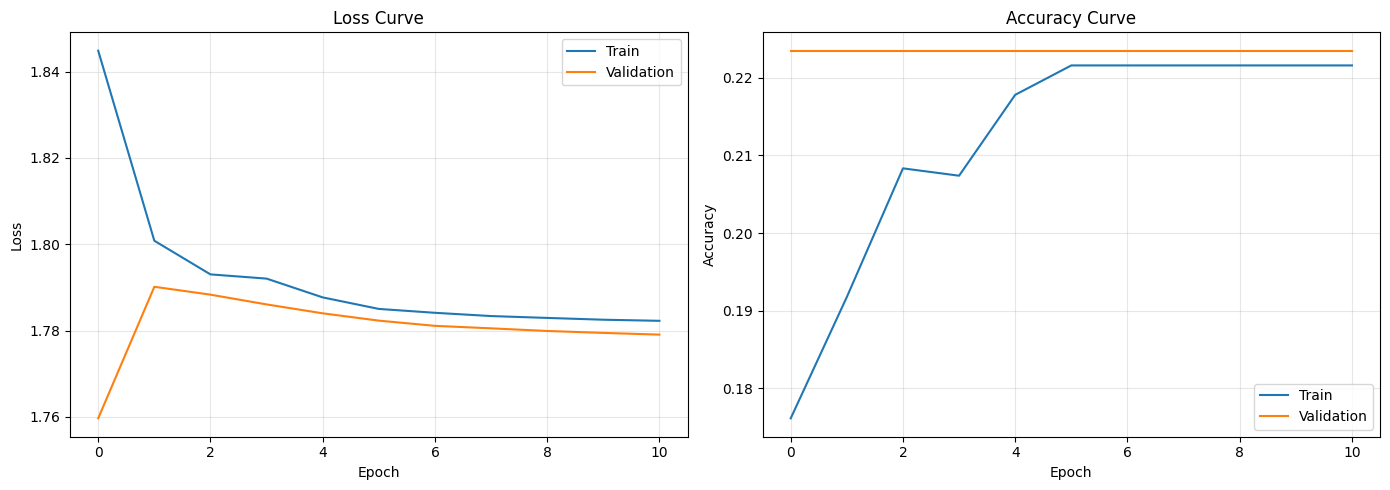

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'emotion_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

/root/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       happy       0.00      0.00      0.00        39
       angry       0.00      0.00      0.00        36
         sad       0.00      0.00      0.00        37
     neutral       0.00      0.00      0.00        53
        fear       0.00      0.00      0.00        42
    surprise       0.22      1.00      0.36        57

    accuracy                           0.22       264
   macro avg       0.04      0.17      0.06       264
weighted avg       0.05      0.22      0.08       264



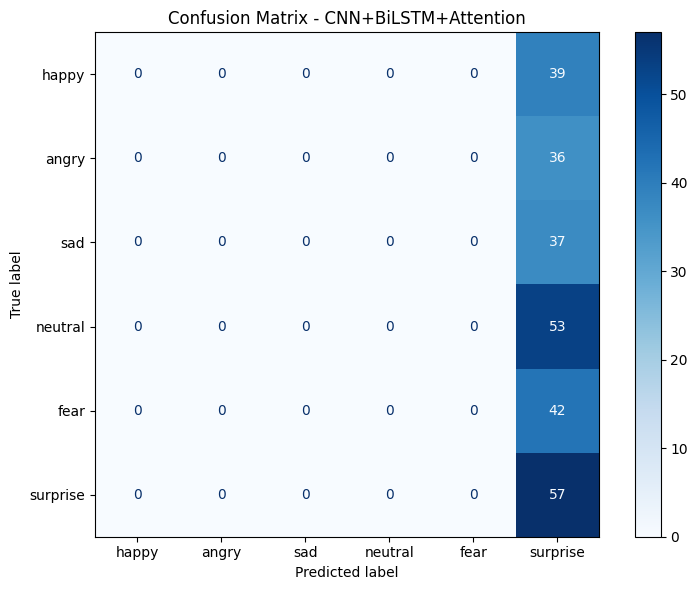

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from utils.audio_utils import EMOTION_LABELS

model.load_state_dict(best_state)
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        preds = model(feats).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

print(classification_report(all_labels_list, all_preds, target_names=EMOTION_LABELS))

cm = confusion_matrix(all_labels_list, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - CNN+BiLSTM+Attention')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'confusion_matrix.png'), dpi=150)
plt.show()